# Day 14 In-Class Assignment: Approval Ratings


### <p style="text-align: right;"> &#9989; Put your name here.</p>

#### <p style="text-align: right;"> &#9989; Put your group member names here.</p>

### Update posted March 4, 2024 after class

This module was way too long so we didn't finish in class. So the plan is:
- Prior to Wednesday's class, you should have completed up to (not including) the section called `Linear Regression`. 
- There is no pre-class assignment submission required. 

## How popular/unpopular is Joe Biden?

<img src="https://raw.githubusercontent.com/msu-cmse-courses/cmse801-supplemental/main/Day-14/popularity.png" width=1200px>

## Fitting approval rating data and making predictions

In this assignment we're going to look at how we might use a meaningful model to understand data.

The **learning goals** of the assignment are to:
* Discuss the role that models play in our understanding of the world around us and how models can be used to make predictions.
* Practice using the SciPy `curve_fit()` function to fit a specific model to data
* Practice using resources like ChatGPT
* Interpret the results of our best fit model
* Use our best fit model to calculate new values and forecast future behavior

### Assignment instructions

Work with your group to complete this assignment. Instructions for submitting this assignment are at the end of the notebook. The assignment is due at the end of class.

The following FiveThirtyEight article uses this data and updates it regularly: https://projects.fivethirtyeight.com/biden-approval-rating/

##ANSWER ## 
### Instructor notes from Liz Spring 2024

- This is way too long with way too many ideas. Needs to be simplified if they have a chance of making it to the end. I split it up into two days to handle it since they only got as far as cleaning the data and were just starting the Linear Regression bit at the end of class day 1. 
- Also should pick which pollster to use for them. Some of the choices have not nearly enough data. 
- I also think this needs to be a non-time based data set. This got very confusing particularly with trying to explain the train/test split idea (some of them knew enough to find the sklearn function which doesn't make sense in this particular context).

---
### Loading and viewing the data

On the class website, there is a file named `biden_ratings_2023.csv` make sure you download that file and put it in the same place as this jupyter notebook. This is a dataset containing the results of different polls about Biden's approval rating. 

&#9989; **Task**: Using Pandas, **read in the data file**  and save the numpy array as `data_2023`. **Look at the data** by displaying the dataframe or information about the dataframe using some of the Pandas functions you've learned up to this point. 

In [32]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [33]:
# Put your code to read in the dataset and display the first few rows

In [34]:
### ANSWER ###
data_2023 = pd.read_csv("biden_ratings_2023.csv")
data_2023.head()


,poll_id,pollster_id,pollster,sponsor_ids,sponsors,display_name,pollster_rating_id,pollster_rating_name,fte_grade,methodology,...,notes,url,source,internal,partisan,politician_id,politician,yes,no,alternate_answers
0,84406,399,Rasmussen (Pulse Opinion Research),2006,Matt Palumbo's Fact-Checking the Fact-Checkers,Rasmussen Reports,277,Rasmussen Reports,B,IVR/Online Panel,...,NaN,https://www.rasmussenreports.com/public_conten...,NaN,False,NaN,42,Joe Biden,43.0,54.0,0.0
1,84408,1205,Marist,"373,765",NPR | PBS NewsHour,Marist College,183,Marist College,A,Live Phone/Online Panel/Text,...,NaN,https://maristpoll.marist.edu/polls/the-war-be...,NaN,False,NaN,42,Joe Biden,43.0,52.0,6.0
2,84408,1205,Marist,"373,765",NPR | PBS NewsHour,Marist College,183,Marist College,A,Live Phone/Online Panel/Text,...,NaN,https://maristpoll.marist.edu/polls/the-war-be...,NaN,False,NaN,42,Joe Biden,44.0,52.0,4.0
3,84384,399,Rasmussen (Pulse Opinion Research),2006,Matt Palumbo's Fact-Checking the Fact-Checkers,Rasmussen Reports,277,Rasmussen Reports,B,IVR/Online Panel,...,NaN,https://www.rasmussenreports.com/public_conten...,NaN,False,NaN,42,Joe Biden,43.0,56.0,0.0
4,84409,1554,RMG Research,NaN,NaN,RMG Research,555,RMG Research,B-,NaN,...,NaN,https://twitter.com/RMG_Research/status/171292...,NaN,False,NaN,42,Joe Biden,39.0,56.0,0.0


&#9989; **Task:** Answer these questions

1. How many columns and rows does the dataset have ?
2. What is the `type` of the `start_date` and `end_date` columns?
3. What information is contained in the `yes` and `no` columns?

<font size=+3>&#9998;</font> *Put your answers here*

In [35]:
# Put any code you might need to answer the questions here.

In [36]:
### ANSWER 
# 1. 4043 rows, 34 columns
print(len(data_2023))

# This returns a pandas series with the info for all columns 
print(data_2023.dtypes)

# This is to take a look at the yes/no columns
# It has a percentage of approval for the given info
print(data_2023.yes.head())


4043
poll_id                      int64
pollster_id                  int64
pollster                    object
sponsor_ids                 object
sponsors                    object
display_name                object
pollster_rating_id           int64
pollster_rating_name        object
fte_grade                   object
methodology                 object
transparency_score         float64
state                      float64
start_date                  object
end_date                    object
sponsor_candidate_id       float64
sponsor_candidate          float64
sponsor_candidate_party    float64
question_id                  int64
sample_size                float64
population                  object
subpopulation              float64
population_full             object
tracking                    object
created_at                  object
notes                       object
url                         object
source                     float64
internal                      bool
partisan       

The code below makes a **scatter plot** of approval (`yes` column) and disapproval (`no` column) ratings vs `end_date`. 

&#9989; **Task:** Run the code. What do you notice? 

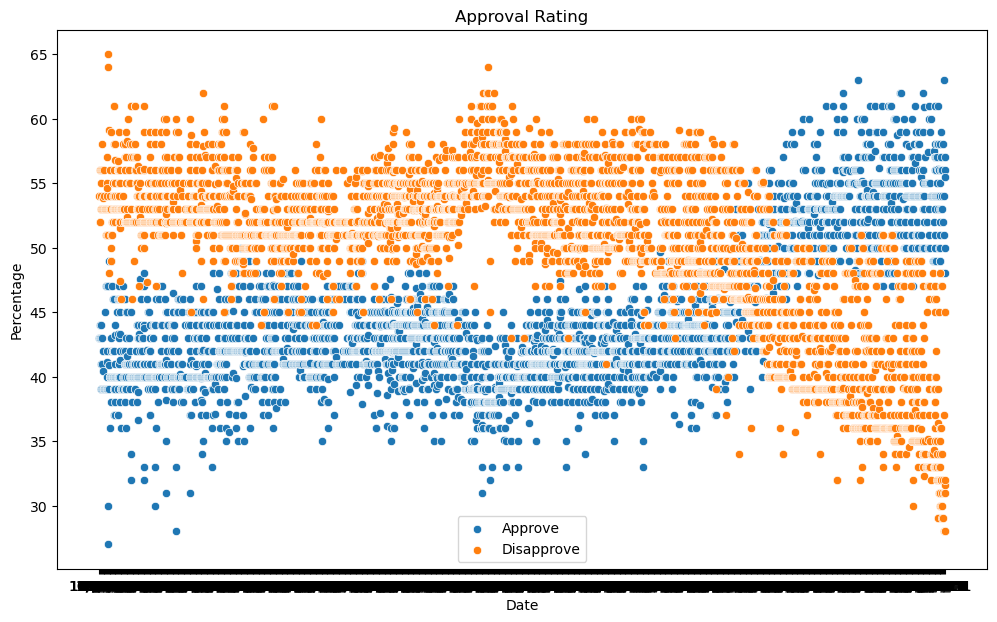

In [37]:
fig, ax = plt.subplots(1,1, figsize = (12,7))
# Scatter plot for 'Yes' column
sns.scatterplot(data = data_2023, x = "end_date", y = "yes", label = 'Approve', ax = ax)
# Scatter plot for 'No' column
sns.scatterplot(data = data_2023, x = "end_date", y = "no", label = 'Disapprove',  ax = ax)
# Setting the title and labels
_ = ax.set( title = "Approval Rating", xlabel = "Date", ylabel = "Percentage")


<font size=+3>&#9998;</font> *Put your answers here*

Mmmh that plot doesn't look that useful. The first thing you may notice is that the plot looks reversed from the one shown at the top of the notebook. Biden's disapproval actually increases over time while it appears to descrease in the plot we made. The second thing is that the $x$-axis is pretty messy. That is because `end_date` is a `string` and `seaborn` doesn't recognize it as a date. Fortunately, `pandas` has a specific `type` for dates and times. 

&#9989; **Task:** Using [`pandas.to_datetime`](https://pandas.pydata.org/docs/reference/api/pandas.to_datetime.html) convert the column `end_date` to a `datetime` object. Then **remake the plot**.

**IMPORTANT:** Read the documentation and look for a `format` option, you need to know how the dates are stored in the dataset.

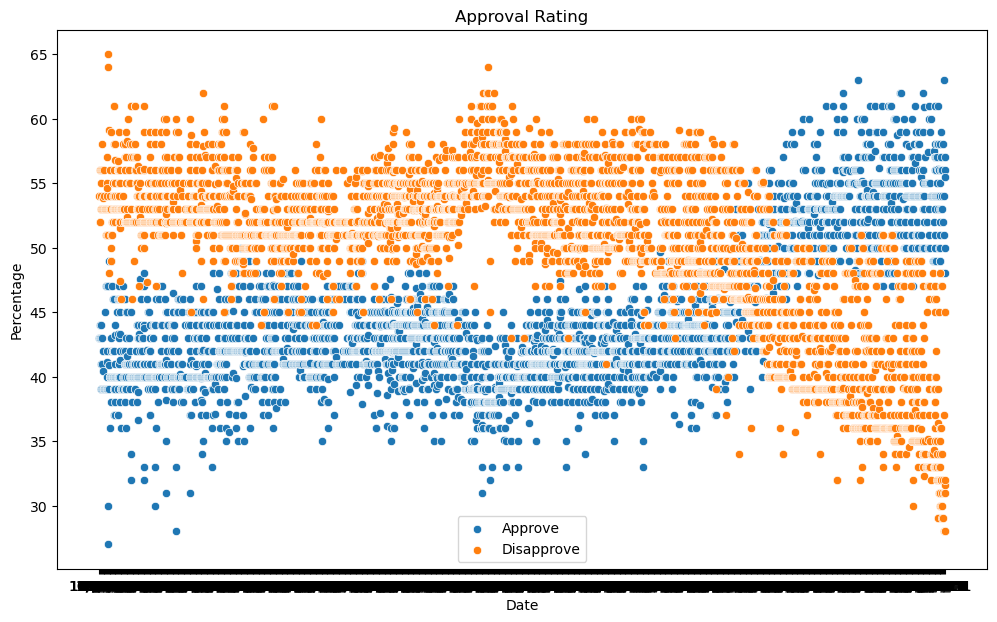

In [38]:
# Put your code to convert 'end_date' column to pandas datetime format with the specific format here
...

fig, ax = plt.subplots(1,1, figsize = (12,7))
# Scatter plot for 'Yes' column
sns.scatterplot(data = data_2023, x = "end_date", y = "yes", label = 'Approve', ax = ax)
# Scatter plot for 'No' column
sns.scatterplot(data = data_2023, x = "end_date", y = "no", label = 'Disapprove',  ax = ax)
# Setting the title and labels
_ = ax.set( title = "Approval Rating", xlabel = "Date", ylabel = "Percentage")


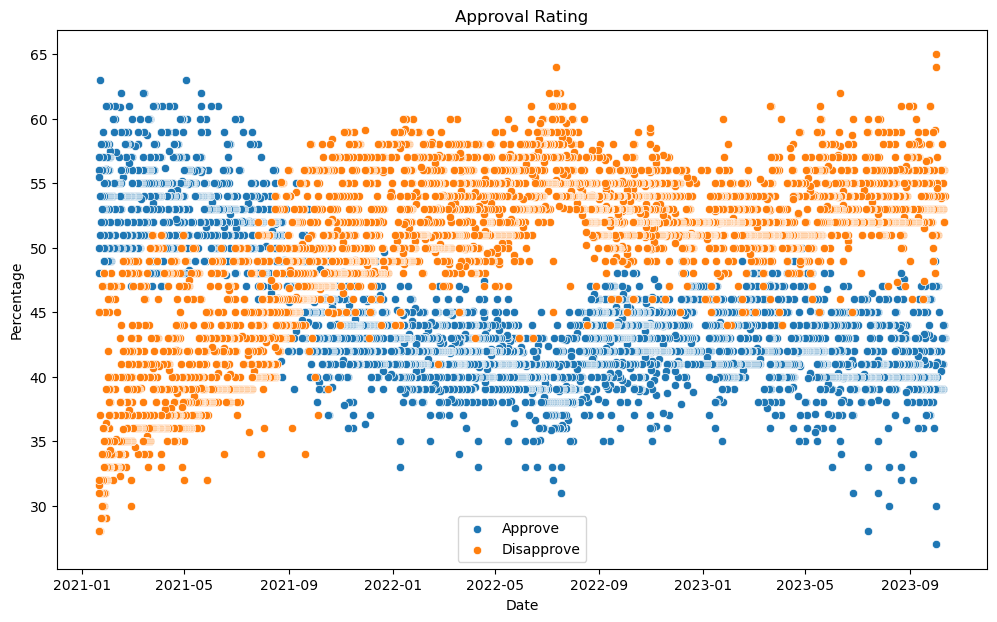

In [39]:
### ANSWER

# Convert 'end_date' column to pandas datetime format with the specific format
data_2023['end_date'] = pd.to_datetime(data_2023['end_date'], 
                                       format='%m/%d/%y')

# # Convert the pandas datetime to numpy datetime64 object
# data_2023['end_date_np'] = data_2023['end_date'].values.astype('datetime64[D]')

# # Display the first few rows to confirm the transformation
# data_2023[['end_date', 'end_date_np']].head()

fig, ax = plt.subplots(1,1, figsize = (12,7))
# Scatter plot for 'Yes' column
sns.scatterplot(data = data_2023, x = "end_date", y = "yes", label = 'Approve', ax = ax)
# Scatter plot for 'No' column
sns.scatterplot(data = data_2023, x = "end_date", y = "no", label = 'Disapprove',  ax = ax)
# Setting the title and labels
_ = ax.set( title = "Approval Rating", xlabel = "Date", ylabel = "Percentage")


In [40]:
## ANSWER ##
# Note that the output type is now ` datetime64[ns]`
data_2023.dtypes

poll_id                             int64
pollster_id                         int64
pollster                           object
sponsor_ids                        object
sponsors                           object
display_name                       object
pollster_rating_id                  int64
pollster_rating_name               object
fte_grade                          object
methodology                        object
transparency_score                float64
state                             float64
start_date                         object
end_date                   datetime64[ns]
sponsor_candidate_id              float64
sponsor_candidate                 float64
sponsor_candidate_party           float64
question_id                         int64
sample_size                       float64
population                         object
subpopulation                     float64
population_full                    object
tracking                           object
created_at                        

&#9989; **Question:** What does the option `ax` do inside the `scatterplot` function ?

<font size=+3>&#9998;</font> *Put your answers here*

###ANSWER###

*It connects the scatter plots to the axes created in the top line. In this case, we wanted to mess with the figure size, so this way we end up with a larger graph.*

As you can see the dataset contains the results of multiple pollsters. 

&#9989; **Task:** Choose your favorite pollster and using a mask select only their poll results and save them into a dataframe with a different name. Then, display the first 10 rows of `end_date`, `yes`, and `no` only

In [41]:
# Put your code here

In [80]:
### ANSWER

print('Some options:', list(set(data_2023["pollster"]))[:10])
data = data_2023[ data_2023["pollster"] == "Ipsos" ]
# data = data_2023[ data_2023["pollster"] == "Beacon Research/Shaw & Company" ]

data[["end_date", "yes", "no"]].head(10)

Some options: ['Beacon Research/Shaw & Company', 'GreatBlue Research', 'Momentive', 'Global Strategy Group/GBAO/Navigator Research', 'YouGov Blue', 'Winston', 'Benenson Strategy Group/Public Opinion Strategies', 'Marist', 'U. Massachusetts - Lowell', 'co/efficient']


,end_date,yes,no
12,2023-10-08,40.40,53.83
117,2023-09-10,41.61,52.34
241,2023-08-06,40.00,54.00
255,2023-08-01,40.00,55.00
340,2023-07-09,40.17,54.46
453,2023-06-05,41.00,54.00
562,2023-05-07,40.27,54.43
608,2023-04-24,41.00,54.00
645,2023-04-16,39.16,53.78
793,2023-03-05,42.25,51.59


As you can see the data is in descending order, for our code later, we need to reverse the order so that the dates are increasing. 

&#9989; **Task:** Ask [ChatGPT](https://chat.openai.com) for the code to reverse the order of your dataset such that the date column is in ascending order (or write the code yourself if you know how). Then, display the first 10 rows of `end_date`, `yes`, and `no` only

In [81]:
# Put your code or ChatGPT's code here. Remember to check 
# ChatGPT's answers! 

In [82]:
### ANSWER
data.sort_values(by = "end_date", ascending = True, inplace = True)
data[["end_date", "yes", "no"]].head(10)

/var/folders/lm/dn75vz_d72b1cntn3ncjj10c0000gn/T/ipykernel_36404/3886573148.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.sort_values(by = "end_date", ascending = True, inplace = True)


,end_date,yes,no
4039,2021-01-21,57.00,32.00
4038,2021-01-21,55.47,31.59
3977,2021-02-03,57.46,34.28
3958,2021-02-10,57.42,35.18
3929,2021-02-18,55.50,35.95
3901,2021-02-25,56.54,37.44
3871,2021-03-04,57.86,34.53
3843,2021-03-11,53.76,39.11
3821,2021-03-18,58.74,35.39
3790,2021-03-25,53.46,40.66


Now the data is in the correct order, but it appears that polls results are taken only every few days. Let's try to fix that by filling in the extra days.

&#9989; **Task:** Ask [ChatGPT](chat.openai.com) how to create a new array called `days_since_first` which has the same length as your data, where each entry is the number of days in that entry
 since the first row. For example, if the first row has `2021-01-21` and a later entry has `2021-02-03`, then the new array should have a `13` in that later entry. Print out the new array to make sure ChatGPT did what you wanted. 

In [83]:
# Put ChatGPT's code here (or your own)

In [84]:
### ANSWER
#  Create a new array containing the days since the first row
days_since_first = (data['end_date'] - data['end_date'].iloc[0]).dt.days
days_since_first

4039      0
4038      0
3977     13
3958     20
3929     28
       ... 
340     899
255     922
241     927
117     962
12      990
Name: end_date, Length: 120, dtype: int64

&#9989; **Task:** Split the array `days_since_first` into two; one array containing the first 80% of the data (which we will use for training/creating a model) and one with the remaining 20% (which we will use for testing the quality of that model). You can ask ChatGPT if you want some help. Call the first array `training_time` and the second array `testing_time`. 

Split the `yes` and `no` columns in the same way and give them appropriate names.

Print out the arrays and make sure they are correct 

In [85]:
# Put your code here 

In [86]:
### ANSWER 
# Determine the split index for 80% of the data
split_idx = int(0.8 * len(days_since_first))

# Split the array into two
x_train = days_since_first[:split_idx]
x_test = days_since_first[split_idx:]

print("Training Time:\n", x_train)
print("\nTesting Time:\n", x_test)

Training Time:
 4039      0
4038      0
3977     13
3958     20
3929     28
       ... 
1536    600
1498    607
1453    614
1427    620
1416    621
Name: end_date, Length: 96, dtype: int64

Testing Time:
 1382    628
1342    635
1318    641
1306    642
1255    649
1223    655
1189    663
1153    670
1138    677
1113    684
1083    691
1051    698
985     724
896     745
793     773
645     815
608     823
562     836
453     865
340     899
255     922
241     927
117     962
12      990
Name: end_date, dtype: int64


---
### Linear Regression

Ok. We are now ready to model!

As a first pass, your goal is to produce a fit to the data using a linear model, _i.e._ $y = a x + b$ and a quadratic model, _i.e._ $y = ax^2 + bx + c$. 

&#9989; **Task:** Create a linear fit to the disapproval ratings (or approval ratings, your choice) using `curve_fit`. Make a plot of the disapproval (approval) data along with the best fit line. Once you have this working, do the same for a quadratic model.

**IMPORTANT:** Recall that `end_date` is not a number, but a `datetime` object. The probelm is that `curve_fit` accepts only numbers, but this is why we created the `days_since_first` array to begin with. Use the `training_set` as your independent variable. Make sure the arrays are the same length.

In [87]:
#Put your code here


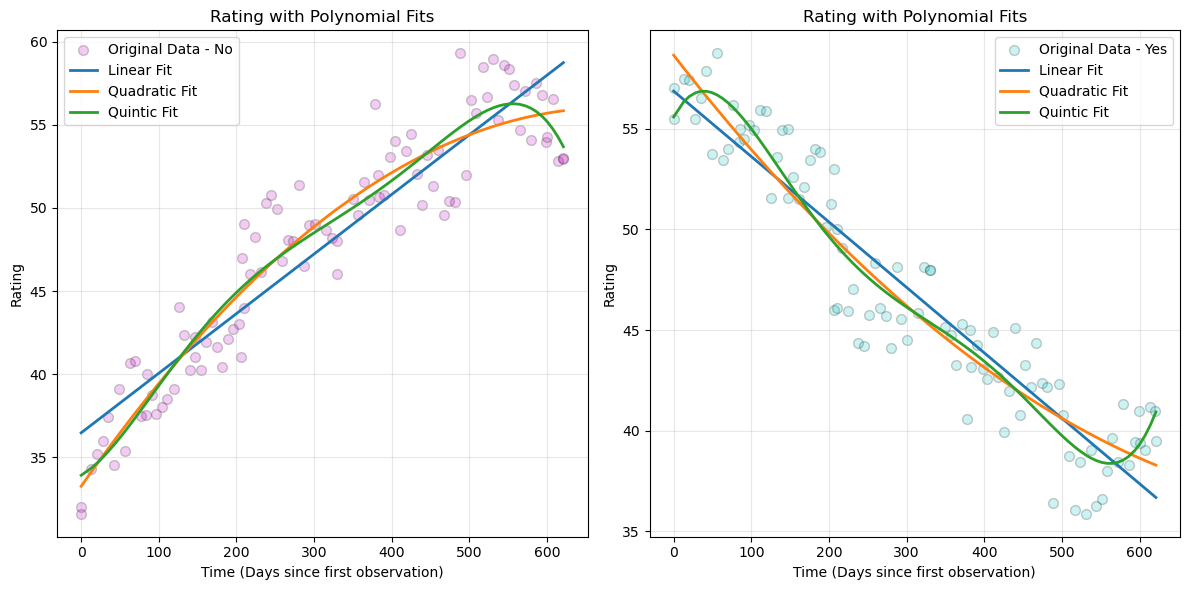

In [88]:
### ANSWER
from scipy.optimize import curve_fit

# Define the polynomial functions
def linear(x, a, b):
    return a * x + b

def quadratic(x, a, b, c):
    return a * x**2 + b * x + c

def quintic(x, a, b, c, d, e,f): #Note we didn't ask for this one
    return a * x**5 + b * x**4 + c * x**3 + d * x**2 + e *x + f

# Extracting x (date) and y (yes approval rating) for curve fitting

y_train_no = data['no'].iloc[:split_idx].values
y_train_yes = data['yes'].iloc[:split_idx].values
# training_set = days_since_first[:split_idx]
# testing_set = days_since_first[split_idx:]

# Fit the data to the linear polynomial
params_linear_no, _ = curve_fit(linear, x_train, y_train_no)
params_linear_yes, _ = curve_fit(linear, x_train, y_train_yes)

# Fit the data to the quadratic polynomial
params_quadratic_no, _ = curve_fit(quadratic, x_train, y_train_no)
params_quadratic_yes, _ = curve_fit(quadratic, x_train, y_train_yes)

# Fit the data to the quadratic polynomial
params_quintic_no, _ = curve_fit(quintic, x_train, y_train_no)
params_quintic_yes, _ = curve_fit(quintic, x_train, y_train_yes)

# Generate fitted data for plotting
y_linear_fit_no = linear(x_train, *params_linear_no)
y_quadratic_fit_no = quadratic(x_train, *params_quadratic_no)
y_quintic_fit_no = quintic(x_train, *params_quintic_no)

y_linear_fit_yes = linear(x_train, *params_linear_yes)
y_quadratic_fit_yes = quadratic(x_train, *params_quadratic_yes)
y_quintic_fit_yes = quintic(x_train, *params_quintic_yes)


# Plotting the original data and the polynomial fits
fig, ax = plt.subplots(1,2, figsize = (12, 6))
ax[0].scatter(x_train, y_train_no, s = 50, color='m', ec = 'k', label='Original Data - No', alpha = 0.2)
ax[0].plot(x_train, y_linear_fit_no, lw = 2, label='Linear Fit')
ax[0].plot(x_train, y_quadratic_fit_no, lw = 2,  label='Quadratic Fit')
ax[0].plot(x_train, y_quintic_fit_no,lw = 2,   label='Quintic Fit')

ax[1].scatter(x_train, y_train_yes, s = 50, color='c', ec = 'k', label='Original Data - Yes', alpha = 0.2)
ax[1].plot(x_train, y_linear_fit_yes, lw = 2,  label='Linear Fit')
ax[1].plot(x_train, y_quadratic_fit_yes, lw = 2, label='Quadratic Fit')
ax[1].plot(x_train, y_quintic_fit_yes, lw = 2,  label='Quintic Fit')

# Setting the title and labels
for a in ax:
    a.set( title ='Rating with Polynomial Fits', 
          xlabel = 'Time (Days since first observation)',
          ylabel ='Rating')
    a.legend()
    a.grid(alpha =.3)
    
plt.tight_layout()
plt.show()

&#9989; **Task:** What are the parameters for your best fit? **Print out those parameter values**. *Something to think about*: once you have your best fit parameters, what's the easiest way to use those values to plot your model? 

In [89]:
# Put your code here

In [90]:
### ANSWER
print(f"Linear fit parameters:\n a = {params_linear_no[0]:.2e}, b = {params_linear_no[1]:.2e}")
print(f"Quadratic fit parameters:\n a = {params_quadratic_no[0]:.2e}, b = {params_quadratic_no[1]:.2e}, c = {params_quadratic_no[2]:.2e}")
print(f"Quintic fit parameters:\n", params_quintic_no)

Linear fit parameters:
 a = 3.59e-02, b = 3.65e+01
Quadratic fit parameters:
 a = -4.89e-05, b = 6.68e-02, c = 3.32e+01
Quintic fit parameters:
 [-3.67214220e-12  5.24392315e-09 -2.59801427e-06  4.77809201e-04
  2.73238639e-02  3.39020693e+01]


### Fitting with an arbitrary function

What if we think that the data follows a function with a form that is different than that of a polynomial? This is where curvefit comes in.  Let's try fitting the approval and disapproval ratings using a cosine function, the similar to the one from our pre-class assignment:

$$ f(x) = \frac{A}{1 + C \exp(- B x) } $$

&#9989; **Task:** Define a python function that computes the above mathematical function and then **use that function to fit the data using SciPy's `curve_fit` function**. Plot the resulting fit along with the data for just the disapproval ratings.

Is $f(x)$ a good choice for fitting the data? If not, is there a reason why this is the case? Does it mean the function is a bad choice or is the `curve_fit` function just not returning sensible results?

In [91]:
# Put your code here

/Users/liz/anaconda3/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/liz/anaconda3/lib/python3.10/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


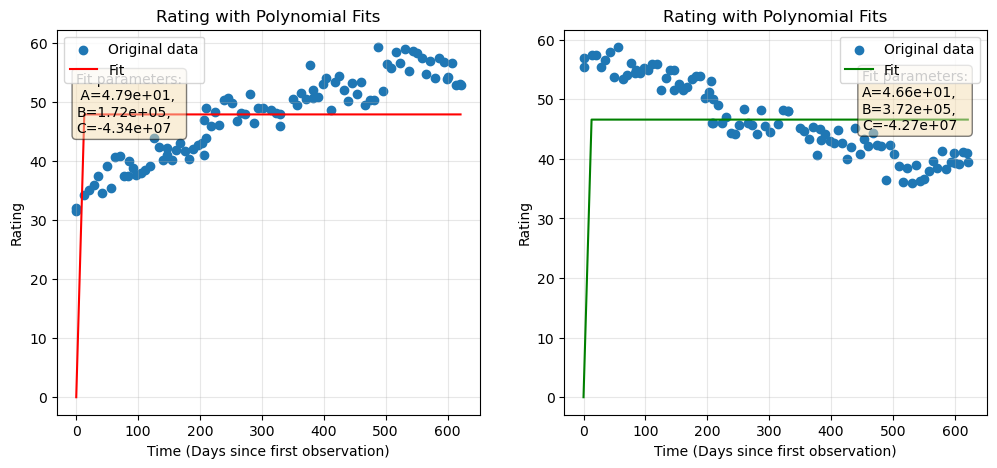

In [92]:
### ANSWER  ###
def my_func(x, A, B, C):
    return A/ (1  + C * np.exp( - B*x)  ) 

popt_no, pcov = curve_fit(my_func, x_train, y_train_no)
popt_yes, pcov = curve_fit(my_func, x_train, y_train_yes)

fig, ax = plt.subplots(1,2, figsize = (12,5))
ax[0].scatter(x_train, y_train_no, label = 'Original data')
ax[0].plot(x_train, my_func(x_train, *popt_no), 'r-', label='Fit')
# Add the provided text with fit parameters to the plot
ax[0].text(0, 55, 
           f"Fit parameters:\n A={popt_no[0]:.2e},\nB={popt_no[1]:.2e},\nC={popt_no[2]:.2e}", 
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax[1].scatter(x_train, y_train_yes, label = 'Original data')
ax[1].plot(x_train, my_func(x_train, *popt_yes), 'g-', label='Fit')
# Add the provided text with fit parameters to the plot
ax[1].text(450, 55, 
           f"Fit parameters:\nA={popt_yes[0]:.2e},\nB={popt_yes[1]:.2e},\nC={popt_yes[2]:.2e}", 
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Setting the title and labels
for a in ax:
    a.set( title ='Rating with Polynomial Fits', 
          xlabel = 'Time (Days since first observation)',
          ylabel ='Rating')
    a.legend()
    a.grid(alpha =.3)


# plt.tight_layout()
# plt.show()

# print(f"\nApproval Fit parameters:\n A={popt_yes[0]:.2e}, B={popt_yes[1]:.2e}, C={popt_yes[2]:.2e}")
# print(f"\nDisapproval Fit parameters:\n A={popt_no[0]:.2e}, B={popt_no[1]:.2e}, C={popt_no[2]:.2e}")

When you first try running `curve_fit()`, you might get a warning and you might get results that don't make sense. Sometimes `curve_fit()` will fail to find a good fit if the initial guess for the best fit parameters is too far off. How would you fix this? Look at the [documentation for `curve_fit`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), especially the `p0` argument, and see if you and your group can figure out how to overcome this issue. What might be reasonable starting guesses for the initial values of `A,B,C`? **Hint**: revisit the plot from above and the parameters that were used to make those models.

&#9989; **Task:** Rerun your code above, but using new initial values.

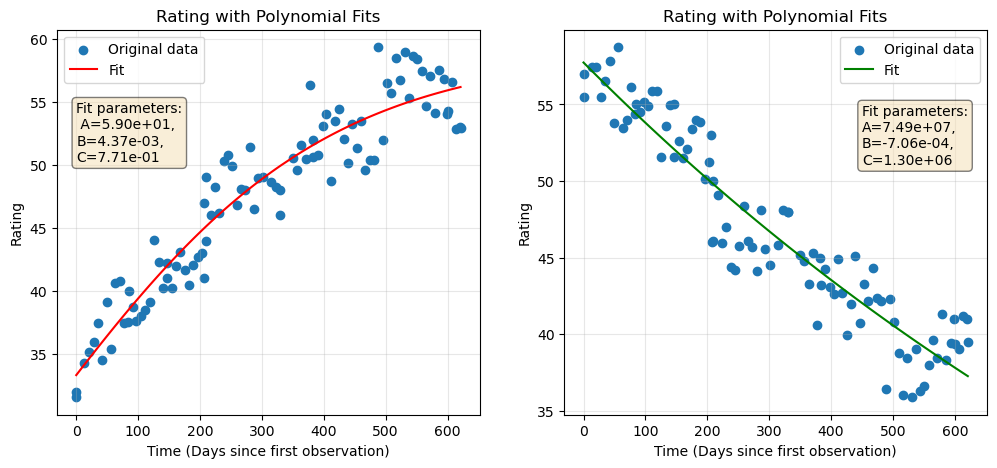

In [101]:
### ANSWER (if you provide an initial guess for the parameters) ###
def my_func(x, A, B, C):
    return A/ (1  + C * np.exp( - B*x)  ) 

# popt_no, pcov = curve_fit(my_func, x_train, y_train_no, p0 = [55, 1, .5])
# popt_yes, pcov = curve_fit(my_func, x_train, y_train_yes, p0 = [35, 1, -0.3])

# One option for choice of initial guess: Set A to be approx the y-intercept, 
#       B to be 0 (so no exponential), and C to be 1
popt_no, pcov = curve_fit(my_func, x_train, y_train_no, p0 = [55, 0, 1])
popt_yes, pcov = curve_fit(my_func, x_train, y_train_yes, p0 = [35, 0, 1])

fig, ax = plt.subplots(1,2, figsize = (12,5))
ax[0].scatter(x_train, y_train_no, label = 'Original data')
ax[0].plot(x_train, my_func(x_train, *popt_no), 'r-', label='Fit')
# Add the provided text with fit parameters to the plot
ax[0].text(0, 55, 
           f"Fit parameters:\n A={popt_no[0]:.2e},\nB={popt_no[1]:.2e},\nC={popt_no[2]:.2e}", 
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax[1].scatter(x_train, y_train_yes, label = 'Original data')
ax[1].plot(x_train, my_func(x_train, *popt_yes), 'g-', label='Fit')
# Add the provided text with fit parameters to the plot
ax[1].text(450, 55, 
           f"Fit parameters:\nA={popt_yes[0]:.2e},\nB={popt_yes[1]:.2e},\nC={popt_yes[2]:.2e}", 
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Setting the title and labels
for a in ax:
    a.set( title ='Rating with Polynomial Fits', 
          xlabel = 'Time (Days since first observation)',
          ylabel ='Rating')
    a.legend()
    a.grid(alpha =.3)


# plt.tight_layout()
# plt.show()

# print(f"\nApproval Fit parameters:\n A={popt_yes[0]:.2e}, B={popt_yes[1]:.2e}, C={popt_yes[2]:.2e}")
# print(f"\nDisapproval Fit parameters:\n A={popt_no[0]:.2e}, B={popt_no[1]:.2e}, C={popt_no[2]:.2e}")

---
## Comparing our fit to new data

One of the useful features of coming up with a best fit model to a set of data is that we can use that model to make predictions about what new data might look like.

&#9989; **Task:** Using your linear fit and another best fit of your choosing, make a plot that predicts the test dataset. Specifically, we just want to extend the best fit lines an additional ~400 days.

In [56]:
# Put your code here

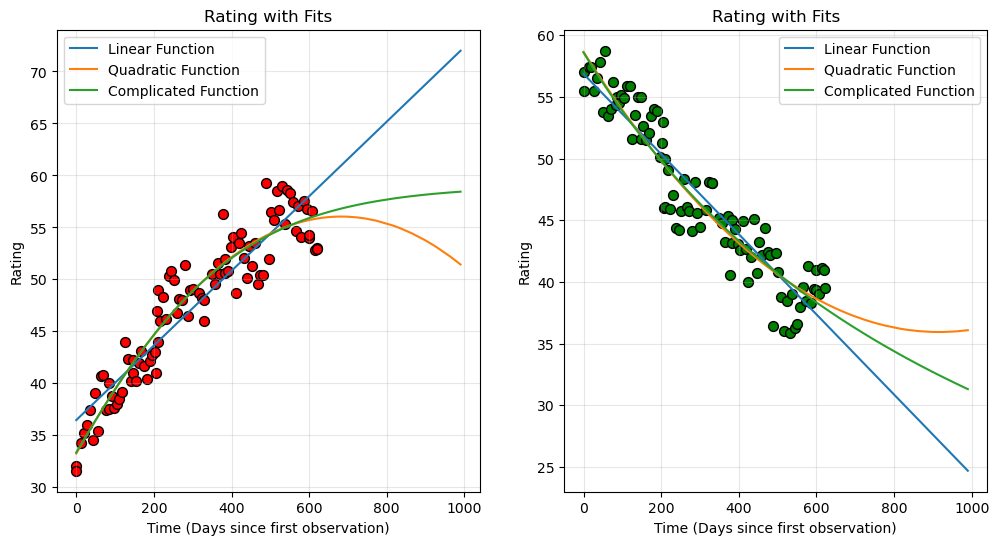

In [57]:
### ANSWER ###
y_test_no = data["no"].iloc[split_idx:].values
y_test_yes = data["yes"].iloc[split_idx:].values

fig, ax = plt.subplots(1,2, figsize=(12,6))
# Training set
ax[0].scatter(x_train, y_train_no, c = 'r', edgecolor = 'k', s = 50)
ax[1].scatter(x_train, y_train_yes, c = 'g', edgecolor = 'k', s = 50)

# Testing set
# ax[0].scatter(x_test, y_test_no, c = 'm', edgecolor = 'k', s = 50)
# ax[1].scatter(x_test, y_test_yes, c = 'c', edgecolor = 'k', s = 50)

# No Fits
x_total = np.append(x_train, x_test)
ax[0].plot(x_total, linear(x_total, *params_linear_no), label = 'Linear Function')
ax[0].plot(x_total, quadratic(x_total, *params_quadratic_no), label = 'Quadratic Function')
# ax[0].plot(x_total, quintic(x_total, *params_quintic_no), label = 'Quintic Function')
ax[0].plot(x_total, my_func(x_total, *popt_no), label = 'Complicated Function')
# Yes Fits
ax[1].plot(x_total, linear(x_total, *params_linear_yes), label = 'Linear Function')
ax[1].plot(x_total, quadratic(x_total, *params_quadratic_yes), label = 'Quadratic Function')
# ax[1].plot(x_total, quintic(x_total, *params_quintic_yes), label = 'Quintic Function')
ax[1].plot(x_total, my_func(x_total, *popt_yes), label = 'Complicated Function')

for a in ax:
    a.set( title ='Rating with Fits', 
          xlabel = 'Time (Days since first observation)',
          ylabel ='Rating')
    a.legend()
    a.grid(alpha =.3)


### How well do our models do?

It is now time to use our test data. 

&#9989; **Task:** Plot the test data on the plot above. **How well do your models fit the data?** Can you think of a way that would allow you to quantify how "good" your fit is?

In [58]:
# Put your code here

*Put your answer here*

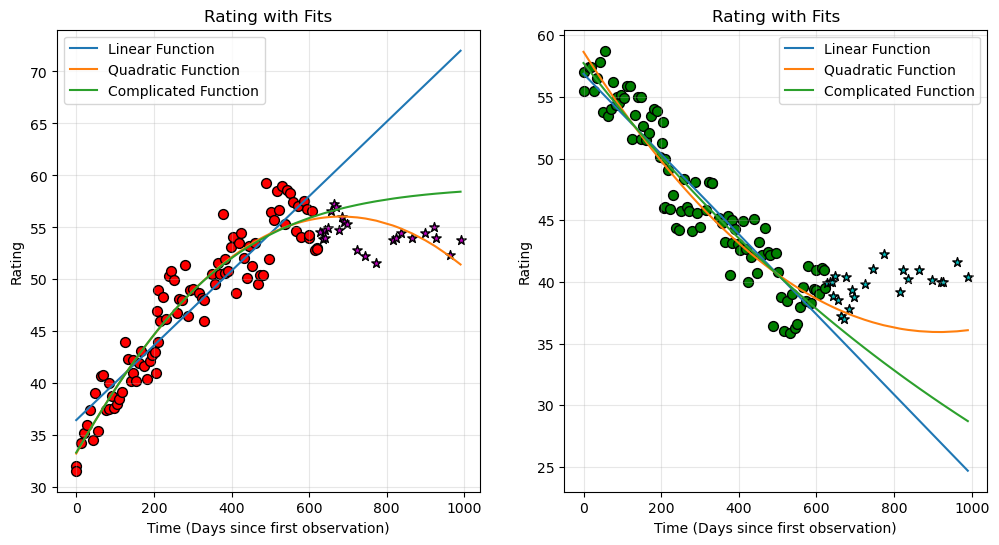

In [103]:
### ANSWER ###

fig, ax = plt.subplots(1,2, figsize=(12,6))
# Training set
ax[0].scatter(x_train, y_train_no, c = 'r', edgecolor = 'k', s = 50)
ax[1].scatter(x_train, y_train_yes, c = 'g', edgecolor = 'k', s = 50)

# Testing set
ax[0].scatter(x_test, y_test_no, c = 'm', edgecolor = 'k', s = 50,marker='*')
ax[1].scatter(x_test, y_test_yes, c = 'c', edgecolor = 'k', s = 50, marker='*')

# No Fits
x_total = np.append(x_train, x_test)
ax[0].plot(x_total, linear(x_total, *params_linear_no), label = 'Linear Function')
ax[0].plot(x_total, quadratic(x_total, *params_quadratic_no), label = 'Quadratic Function')
# ax[0].plot(x_total, quintic(x_total, *params_quintic_no), label = 'Quintic Function')
ax[0].plot(x_total, my_func(x_total, *popt_no), label = 'Complicated Function')
# Yes Fits
ax[1].plot(x_total, linear(x_total, *params_linear_yes), label = 'Linear Function')
ax[1].plot(x_total, quadratic(x_total, *params_quadratic_yes), label = 'Quadratic Function')
# ax[1].plot(x_total, quintic(x_total, *params_quintic_yes), label = 'Quintic Function')
ax[1].plot(x_total, my_func(x_total, *popt_yes), label = 'Complicated Function')

for a in ax:
    a.set( title ='Rating with Fits', 
          xlabel = 'Time (Days since first observation)',
          ylabel ='Rating')
    a.legend()
    a.grid(alpha =.3)


### Fitting all of the data

Sometimes, when we acquire new data, we might have to revise our model if the new data is not supported by the model. This is a common practice in modeling and data science. If you trust the data and your model no longer matches the data, then something must have been wrong about your model!

&#9989; Now that you have all of the data, trying finding the best fit to the full dataset. **What sort of model did you choose? How does it compare to your original fit to only part of the data?**


In [60]:
# Put your code here

*Put your answer here*

/var/folders/lm/dn75vz_d72b1cntn3ncjj10c0000gn/T/ipykernel_36404/2672944768.py:3: RuntimeWarning: overflow encountered in exp
  return A/ (1  + C * np.exp( - B*x)  )


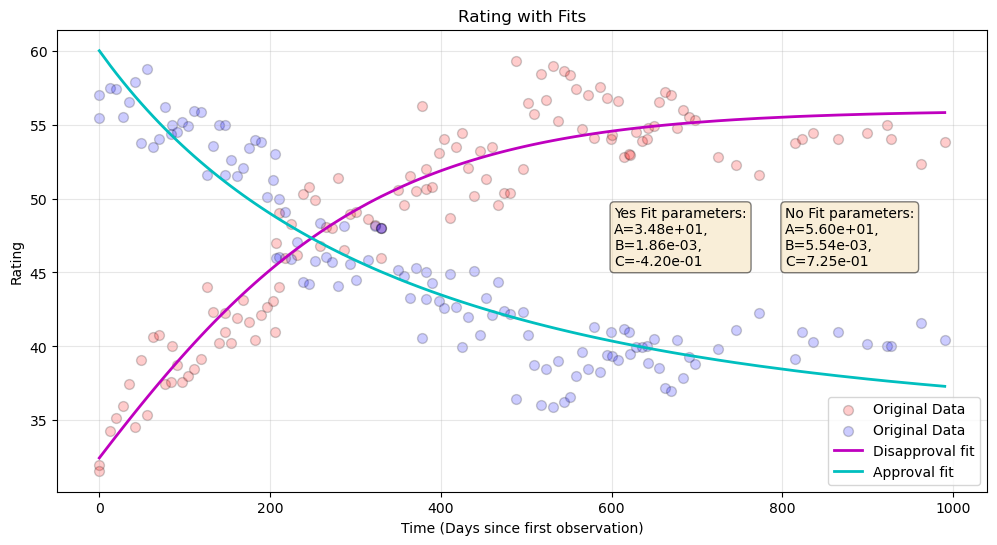

In [61]:
### ANSWER ###

y_total_no = data["no"].values
y_total_yes = data["yes"].values


popt_no, pcov = curve_fit(my_func, x_total, y_total_no, p0 = [55, 1, .5])
popt_yes, pcov = curve_fit(my_func, x_total, y_total_yes, p0 = [35,1, -0.3])


fig, ax = plt.subplots(1,1, figsize=(12,6))
# Training set
ax.scatter(x_total, y_total_no, c = 'r', edgecolor = 'k', s = 50, label = 'Original Data', alpha = 0.2)
ax.scatter(x_total, y_total_yes, c = 'b', edgecolor = 'k', s = 50, label = 'Original Data',  alpha = 0.2)

# No Fits
# x_total = np.append(x_train, x_test)
ax.plot(x_total, my_func(x_total, *popt_no), c = 'm', lw = 2, label = 'Disapproval fit')
# Yes Fits
ax.plot(x_total, my_func(x_total, *popt_yes), c = 'c', lw = 2,label = 'Approval fit')
# Add the provided text with fit parameters to the plot
ax.text(603, 49.5, 
           f"Yes Fit parameters:\nA={popt_yes[0]:.2e},\nB={popt_yes[1]:.2e},\nC={popt_yes[2]:.2e}", 
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
# Add the provided text with fit parameters to the plot
ax.text(803, 49.5, 
           f"No Fit parameters:\nA={popt_no[0]:.2e},\nB={popt_no[1]:.2e},\nC={popt_no[2]:.2e}", 
           verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set( title ='Rating with Fits', 
      xlabel = 'Time (Days since first observation)',
      ylabel ='Rating')
ax.legend()
ax.grid(alpha =.3)


---

## Congratulations, you're done!

Submit this assignment by uploading your notebook to the course Desire2Learn web page.  Go to the "In-Class Assignments" folder, find the appropriate submission link, and upload everything there. Make sure your name is on it!

&#169; Copyright 2023,  [Department of Computational Mathematics, Science and Engineering](https://cmse.msu.edu) at Michigan State University.